# Quickstart

## Installation

### Conda
We recommend using conda to create an environment to run stemFinder. Here is our environment [.yaml file](run_stemFinder_environment.yml)
To create an enviroment with this file, run the following from your command line: 

In [ ]:
conda env create -f run_stemFinder_environment.yml

Once this has been created, then you can activate it:

In [ ]:
conda activate run_stemFinder

In [1]:
# !pip install git+https://{your_token}@github.com/pcahan1/PyStemFinder/

### Install package for leiden clustering

In [ ]:
# !pip install leidenalg

## Setup
In Python, import some packages that we need

In [1]:
import PyStemFinder as psf

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

## Generating toy data sets

As stemFinder metrics examine stochasticity in gene expression it is helpful to be able to generate toy data sets.

Generate toy data set with following parameters:

- 300 cells x 50 genes
- 3 different populations
- overall dropout rate = 25%
- population specific dropout = 25%, 40%, 60%
-  mean expression difference of stochastic genes by population = 0, 2, 4

In [2]:
adata = psf.generate_scRNAseq_test_data(dropout_rate = 0.25, stochastic_dropout_by_population = (0.25, 0.4, 0.6), stochastic_expression_diff=(0, 2, 4))
adata

AnnData object with n_obs × n_vars = 300 × 50

## Dimension reduction

There is no need to normalize this syntheric data. Cluster the data, after running PCA (usually we would exclude stochastic genes, which are var_names[40:45] by default, but in this case, since we are not computing HVG, just keep them in)
kNN
Leiden cluster
Plot

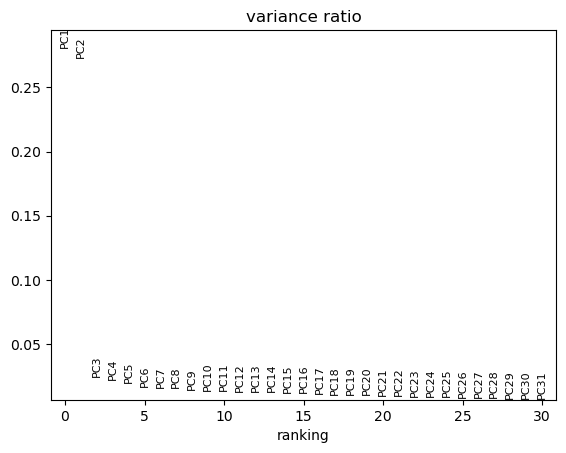

In [3]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

## Cluster the cells

First run kNN, the Leiden cluster, and plot the embedded cells colored by cluster. Note that we set k = log(number of cells).

/opt/homebrew/Caskroom/miniforge/base/envs/pystemfinder/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


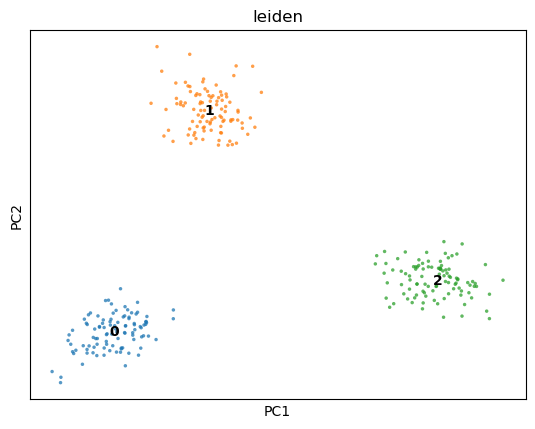

In [5]:
%matplotlib inline
npcs = 2
n_neighbors = int(np.round(np.log(adata.n_obs)))
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=npcs)
sc.tl.leiden(adata, .1)
sc.pl.pca(adata, color=['leiden'], alpha=.75, s=25, legend_loc='on data')

## Visual gene expression
Plot heatmaps of the data, grouped by leiden cluster. First plot counts data. Then plot binarized data, which is what the stemFinder computation is based on.

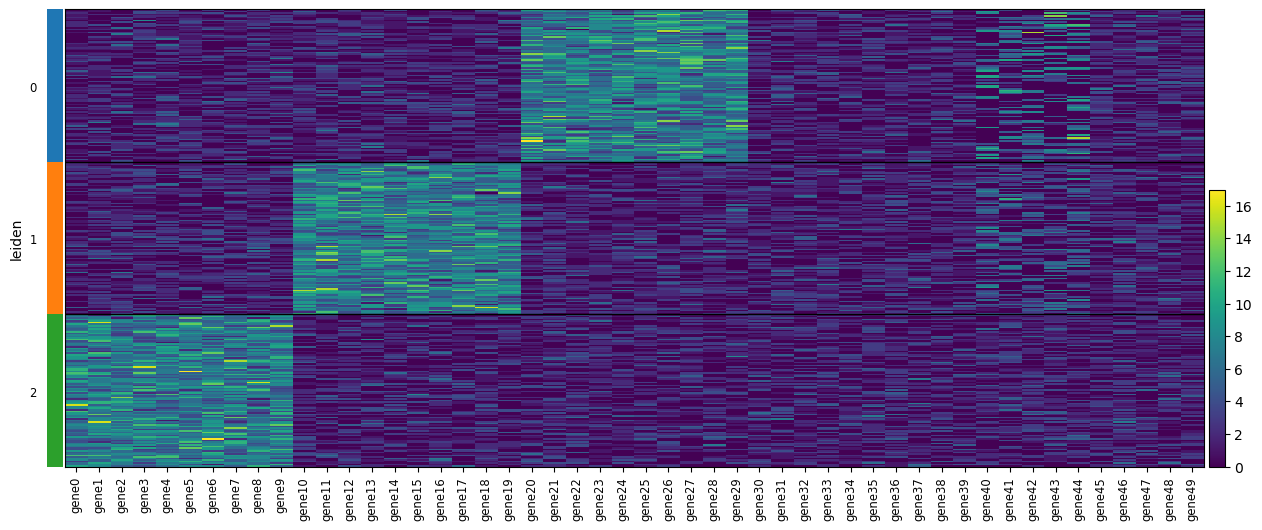

In [6]:
sc.pl.heatmap(adata, var_names=adata.var_names, groupby='leiden')

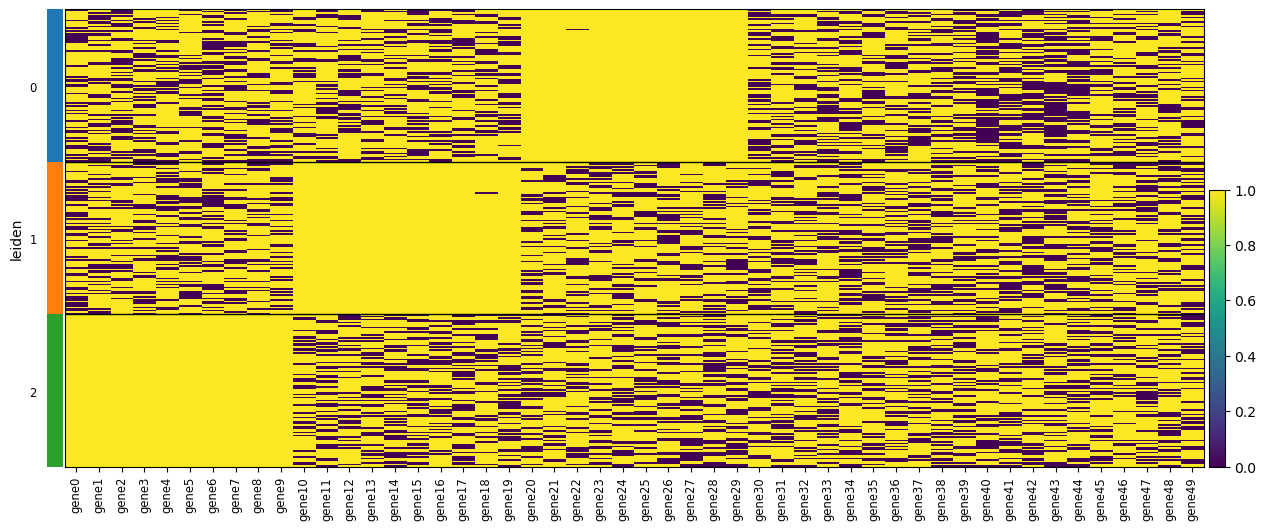

In [7]:
thresh = 0.0
adata.layers['binary'] = psf.binarize_data(adata.X, thresh)
sc.pl.heatmap(adata, var_names=adata.var_names, groupby='leiden', layer='binary')

## stemFinder and diffOmeter

Based on the heatmaps above, try to guess which clusters will have the highest stemFinder (original formulation), diffOmeter (just the average impurity of neighbors). Here, we will compute stemFinder and diffOmeter scores.

..........


/opt/homebrew/Caskroom/miniforge/base/envs/pystemfinder/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


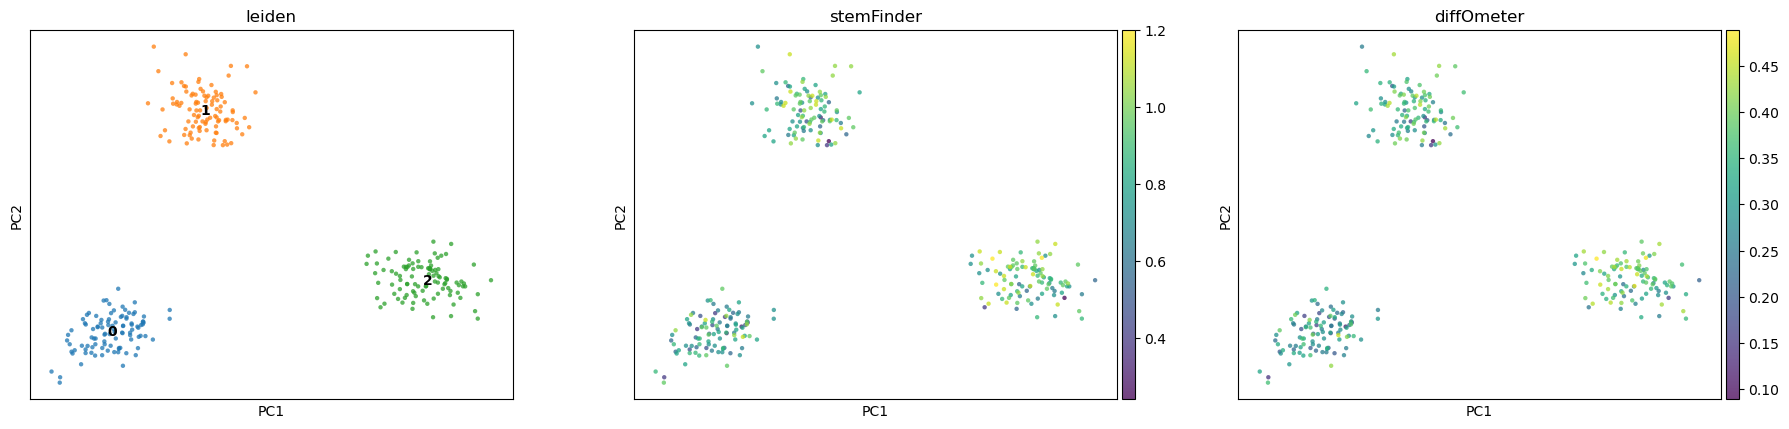

In [13]:
# these are the 'stochastic' genes, which would be cell cycle related genes for real data
geneset_a = adata.var_names[40:45].tolist()
psf.run_stemFinder(adata, n_neighbors, thresh, geneset_a)
psf.diffOmeter(adata, geneset_a, thresh)

sc.pl.pca(adata, color=['leiden', 'stemFinder', 'diffOmeter'], alpha=.75, s=40, legend_loc='on data')


## Visualize scores by cluster
Violin plot to compare score distributions between clusters
Sort the violins by median score

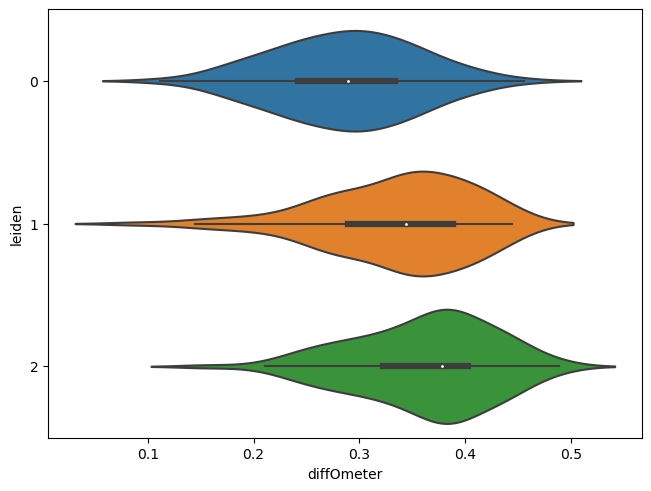

In [11]:
potScore = 'diffOmeter'
catName = "leiden"
group_means = adata.obs.groupby(catName)[potScore].median()
sorted_groups = group_means.sort_values().index.tolist()
df = adata.obs[[catName, potScore]]

plt.subplots(layout="constrained")
sns.violinplot(y=catName, x=potScore, data=df, order=sorted_groups, orient='h') 
plt.show()

The high diffOmeter score (average gini impurity of genes 40-45 for kNN cells) of cluster 2 reflects the greater degree of stocasticity of expression of genes 40-45. This implies a relateively undiffererntiated state. Note that cluster 2 is made of the cells that have a dropout rate that is similar to the background droupout rate.

How does this compare to stemFinder?

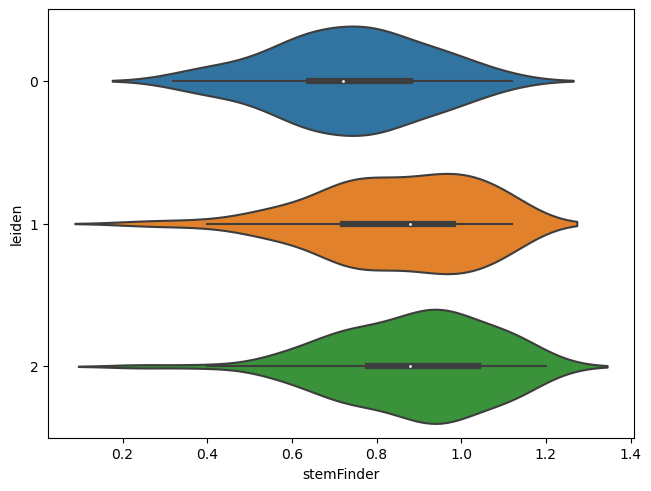

In [12]:
potScore = 'stemFinder'
catName = "leiden"
group_means = adata.obs.groupby(catName)[potScore].median()
sorted_groups = group_means.sort_values().index.tolist()
df = adata.obs[[catName, potScore]]

plt.subplots(layout="constrained")
sns.violinplot(y=catName, x=potScore, data=df, order=sorted_groups, orient='h') 
plt.show()


The UMAP plots showed that the two metrics are highly correlated. Cluster 1 seems to have more of a bi-modal distribution of stemFinder scores.

## Going further
The toy data simulator can be used to explore how these stemness metrics behave across different parameter choices. For example, in what situations does gene standardization matter, and does it have surprising results?